## Importing Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os , random

## Checking structure for balance

In [6]:
def count_images(folder):
    return len(os.listdir(folder))

for split in ["Train", "Validation", "Test"]:
    with_mask = count_images(f"Dataset/{split}/WithMask")
    without_mask = count_images(f"Dataset/{split}/WithoutMask")
    
    print(f"\n{split.upper()}")
    print("With mask:", with_mask)
    print("Without mask:", without_mask)


TRAIN
With mask: 5000
Without mask: 5000

VALIDATION
With mask: 400
Without mask: 400

TEST
With mask: 483
Without mask: 509


## Verify Train / Val / Test Split


In [7]:
total = 0
counts = {}

for split in ["Train", "Validation", "Test"]:
    count = 0
    for cls in ["WithMask", "WithoutMask"]:
        path = f"Dataset/{split}/{cls}"
        count += len(os.listdir(path))
    counts[split] = count
    total += count

for split in counts:
    print(split, ":", counts[split], f"({counts[split]/total:.2%})")

Train : 10000 (84.80%)
Validation : 800 (6.78%)
Test : 992 (8.41%)


## Check image sizes


In [8]:
sizes = set()

folder = "Dataset/Train/WithMask"

for img_name in os.listdir(folder)[:100]:  # sample
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    sizes.add(img.size)

print("Unique sizes:", sizes)

# Images have varying resolutions, so resizing will be applied during preprocessing (e.g., 224×224).

Unique sizes: {(56, 56), (139, 139), (116, 116), (61, 61), (125, 125), (52, 52), (134, 134), (39, 39), (103, 103), (57, 57), (48, 48), (122, 122), (34, 34), (53, 53), (30, 30), (94, 94), (76, 76), (71, 71), (62, 62), (72, 72), (25, 25), (58, 58), (99, 99), (81, 81), (26, 26), (35, 35), (67, 67), (90, 90), (77, 77), (118, 118), (31, 31), (49, 49), (95, 95), (178, 178), (113, 113), (68, 68), (100, 100), (63, 63), (32, 32), (105, 105), (79, 79), (82, 82), (146, 146), (64, 64), (73, 73), (50, 50), (59, 59), (60, 60), (78, 78), (142, 142), (69, 69), (152, 152), (87, 87), (65, 65), (28, 28), (74, 74), (83, 83), (148, 148), (92, 92), (37, 37), (102, 102), (42, 42)}


## Check image quality

In [9]:
bad_images = []

for root, dirs, files in os.walk("Dataset"):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            bad_images.append(path)

print("Bad images:", len(bad_images))

Bad images: 0


## WithoutMask Sample to see image variation

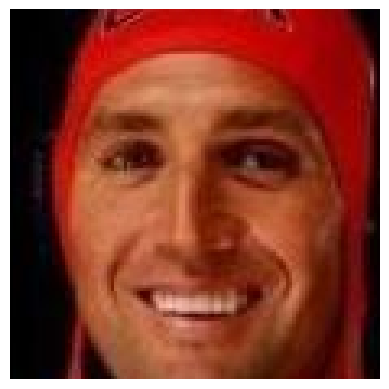

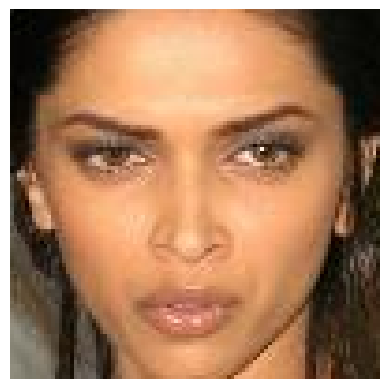

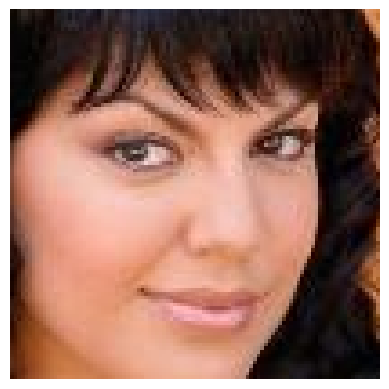

In [23]:
folder = "Dataset/Train/WithoutMask"

images = os.listdir(folder)

for i in range(3):
    img = Image.open(os.path.join(folder, random.choice(images)))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## WithMask Sample to see image variation

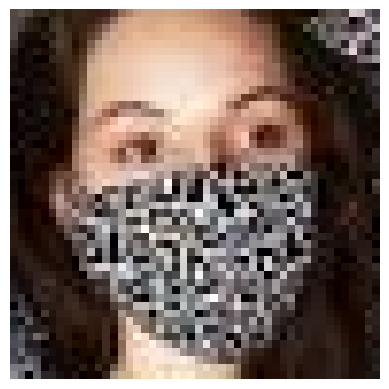

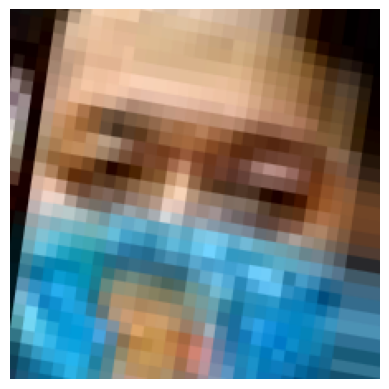

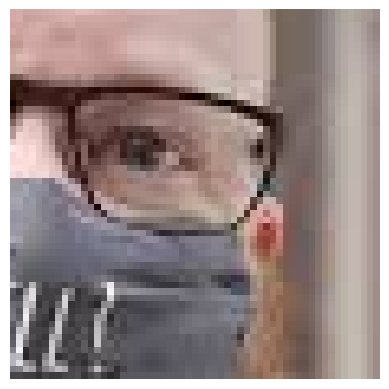

In [24]:
folder = "Dataset/Train/WithMask"
images = os.listdir(folder)

for i in range(3):
    img = Image.open(os.path.join(folder, random.choice(images)))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## Resize Images

In [ ]:
input_base = "Dataset"
output_base = "Dataset_Resized"

splits = ["Train", "Validation", "Test"]
classes = ["WithMask", "WithoutMask"]

for split in splits:
    for cls in classes:
        input_folder = os.path.join(input_base, split, cls)
        output_folder = os.path.join(output_base, split, cls)

        os.makedirs(output_folder, exist_ok=True)

        for img_name in os.listdir(input_folder):
            try:
                img_path = os.path.join(input_folder, img_name)
                img = Image.open(img_path)

                #  Resize
                img = img.resize((224, 224))

                #  Save
                img.save(os.path.join(output_folder, img_name))

            except Exception as e:
                print("Error:", img_name)

In [13]:
img = Image.open("Dataset_Resized/Train/WithMask/4.png")
print(img.size)

(224, 224)


## Normalization

In [ ]:
def load_data(folder):
    data = []
    labels = []

    for label, category in enumerate(["WithMask", "WithoutMask"]):
        path = os.path.join(folder, category)

        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)

                #  Load (already resized)
                img = Image.open(img_path).convert("RGB")

                #  Convert to array
                img = np.array(img)

                #  Normalize
                img = img / 255.0

                data.append(img)
                labels.append(label)

            except:
                continue

    return np.array(data), np.array(labels)

In [19]:
X_train, y_train = load_data("Dataset_Resized/Train")
X_val, y_val = load_data("Dataset_Resized/Validation")
X_test, y_test = load_data("Dataset_Resized/Test")

In [22]:
print("Min:", X_train.min())
print("Max:", X_train.max())
print("Dtype:", X_train.dtype)

Min: 0.0
Max: 1.0
Dtype: float64


## Checking for Non-RGB images

In [1]:
import os
from PIL import Image

non_rgb_images = []

base_path = "Dataset"  # change if needed

for root, dirs, files in os.walk(base_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                if img.mode != "RGB":
                    non_rgb_images.append((file_path, img.mode))
        except:
            continue

print("Total non-RGB images:", len(non_rgb_images))

Total non-RGB images: 0
